# 04 — Exploratory neural data analysis

I inspect the preprocessed population response matrix before fitting advanced latent models. I use real visual features extracted from the Allen natural movie pixels, quantify fine/coarse/confident orientation-label imbalance, visualize representative movie frames, and use circular-shift null tests for temporal neural--stimulus correlations.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from v1_manifold.config import load_config, get_paths, set_global_seed
from v1_manifold.visualization import set_publication_style, save_figure
from v1_manifold.utils import save_table

cfg = load_config(ROOT / "configs" / "default.yaml")
cfg["paths"]["root"] = str(ROOT)
paths = get_paths(cfg)
set_global_seed(cfg["project"]["random_seed"])
set_publication_style()
print(f"Project root: {ROOT}")

Project root: c:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, zscore
from v1_manifold.data_access import get_boc, get_experiment_data, get_stimulus_template
from v1_manifold.preprocessing import load_trial_tensor_h5, repeat_average_population_matrix
from v1_manifold.features import (
    build_frame_feature_table,
    build_real_movie_feature_table,
    fallback_frame_labels,
    assert_real_stimulus_features,
    add_coarse_orientation_target,
    add_confident_orientation_target,
    summarize_class_balance,
    orientation_label_interpretation_table,
)
from v1_manifold.evaluation import stimulus_neural_circular_shift_table
from v1_manifold.visualization import plot_population_heatmap

h5_files = sorted(paths.interim_dir.glob("session_*_tensor.h5"))
if not h5_files:
    raise FileNotFoundError("No trial tensor exists yet. I need to run notebook 03 first.")

tensor_path = h5_files[0]
experiment_id = int(tensor_path.name.split("_")[1])
tensor, R = load_trial_tensor_h5(tensor_path)

# I extract real stimulus features from the actual Allen natural movie pixels.
boc = get_boc(paths.allen_manifest)
data_set = get_experiment_data(boc, experiment_id)
movie = get_stimulus_template(data_set, cfg["preprocessing"]["stimulus_name"])

if movie is None:
    if cfg["features"].get("require_real_stimulus_features", True):
        raise RuntimeError(
            "I could not load the Allen natural movie template. Real stimulus-feature decoding requires "
            "data_set.get_stimulus_template(stimulus_name). I am not falling back to synthetic labels."
        )
    labels = fallback_frame_labels(R.shape[0], cfg["features"]["orientation_bins"], cfg["features"]["spatial_frequency_bins"])
else:
    print("Movie template shape:", np.asarray(movie).shape)
    labels = build_real_movie_feature_table(
        movie,
        n_orientation_bins=cfg["features"]["orientation_bins"],
        n_spatial_frequency_bins=cfg["features"]["spatial_frequency_bins"],
        downsample_factor=cfg["features"].get("stimulus_downsample_factor", 4),
        max_frames=R.shape[0],
    )

population_features = build_frame_feature_table(R, labels=None)
features = population_features.merge(labels, on="movie_frame", how="left")

# This assertion prevents placeholder labels from leaking into final decoding results.
assert_real_stimulus_features(features)

# I add coarse and confidence-aware orientation targets because hard natural-movie
# orientation bins can be imbalanced and ambiguous.
features = add_coarse_orientation_target(
    features,
    top_k=cfg["features"].get("coarse_orientation_top_k", 2),
)
features = add_confident_orientation_target(
    features,
    confidence_quantile=cfg["features"].get("orientation_confidence_quantile", 0.50),
    ambiguous_label=cfg["features"].get("orientation_ambiguous_label", "ambiguous"),
)

base_name = tensor_path.name.replace("_tensor.h5", "")
save_table(features, paths.processed_dir / f"{base_name}_real_frame_features.csv")
# I also save the canonical filename used by downstream notebooks.
save_table(features, paths.processed_dir / f"{base_name}_frame_features.csv")

print("Real stimulus-derived features saved for", len(features), "movie frames")
display(features.head())

c:\Users\Peter\.neuro\Lib\site-packages\allensdk\core\brain_observatory_nwb_data_set.py:43: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


Movie template shape: (900, 304, 608)
Real stimulus-derived features saved for 900 movie frames


,movie_frame,population_mean,population_std,population_l2_norm,n_cells,luminance_mean,luminance_std,rms_contrast,dominant_orientation_bin,dominant_orientation_angle_rad,...,spatial_frequency_energy_bin_1,spatial_frequency_energy_bin_2,spatial_frequency_energy_bin_3,spatial_frequency_energy_bin_4,dominant_orientation_coarse,dominant_orientation_coarse_is_other,orientation_confidence,orientation_confidence_threshold,dominant_orientation_confident,dominant_orientation_confident_is_ambiguous
0,0,0.459886,2.380123,30.949413,163,0.490070,0.173897,0.354841,4,1.767146,...,0.588674,0.237981,0.036750,0.001043,bin_4,False,0.347660,0.351332,ambiguous,True
1,1,0.475428,2.378806,30.971182,163,0.489777,0.172505,0.352212,4,1.767146,...,0.584581,0.238913,0.038509,0.000953,bin_4,False,0.346613,0.351332,ambiguous,True
2,2,0.436005,2.304510,29.943974,163,0.489762,0.172541,0.352296,4,1.767146,...,0.583764,0.239259,0.038441,0.000957,bin_4,False,0.346748,0.351332,ambiguous,True
3,3,0.373745,2.170050,28.113255,163,0.489371,0.171676,0.350809,4,1.767146,...,0.575348,0.243556,0.040149,0.000976,bin_4,False,0.339802,0.351332,ambiguous,True
4,4,0.420181,2.040942,26.603487,163,0.489342,0.171249,0.349959,4,1.767146,...,0.567800,0.251179,0.044694,0.000945,bin_4,False,0.334459,0.351332,ambiguous,True


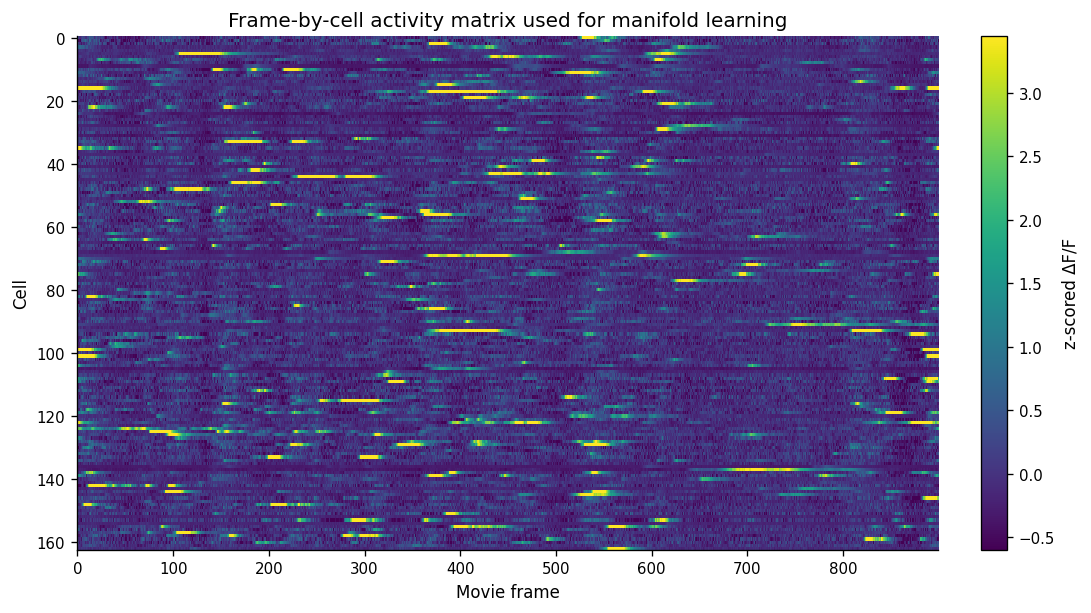

In [3]:
# Robust clipping is only for visualization. The saved tensor and downstream analyses remain unchanged.
R_plot = R.copy()
vmin, vmax = np.nanpercentile(R_plot, [1, 99])

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(R_plot.T, aspect="auto", interpolation="nearest", vmin=vmin, vmax=vmax)
ax.set_xlabel("Movie frame")
ax.set_ylabel("Cell")
ax.set_title("Frame-by-cell activity matrix used for manifold learning")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("z-scored ΔF/F")
save_figure(fig, paths.figures_dir / "04_population_activity_heatmap_robust.png")
plt.show()

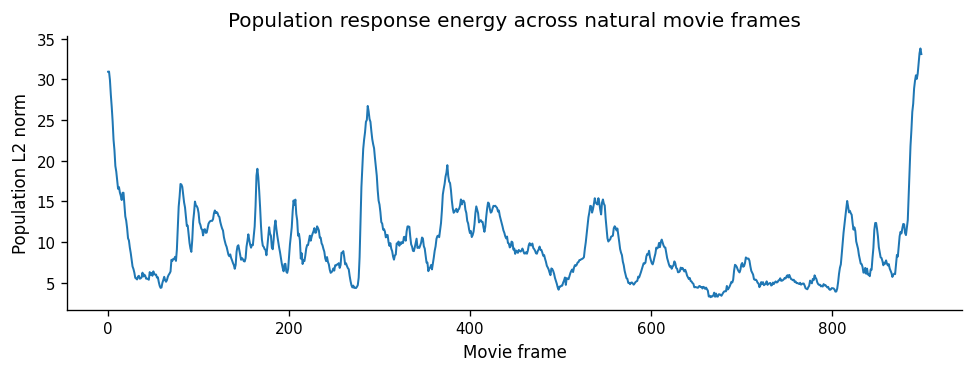

In [4]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(features["movie_frame"], features["population_l2_norm"], linewidth=1.2)
ax.set_xlabel("Movie frame")
ax.set_ylabel("Population L2 norm")
ax.set_title("Population response energy across natural movie frames")
save_figure(fig, paths.figures_dir / "04_population_response_energy.png")
plt.show()

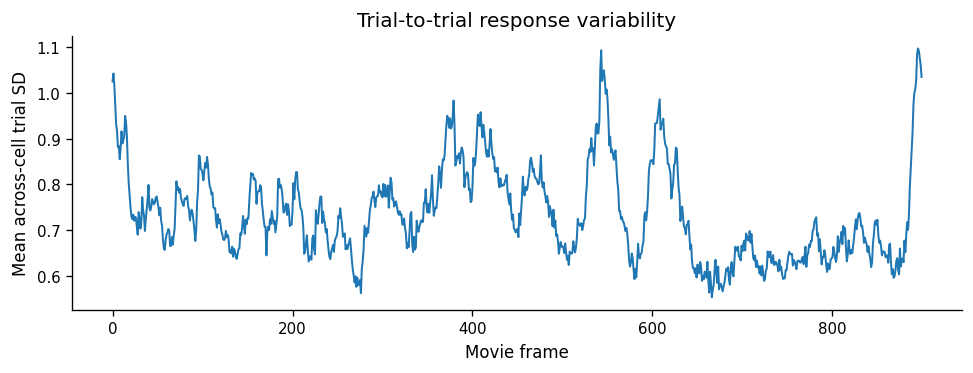

In [5]:
trial_variability = tensor.std(axis=0).mean(axis=0)
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(np.arange(len(trial_variability)), trial_variability, linewidth=1.2)
ax.set_xlabel("Movie frame")
ax.set_ylabel("Mean across-cell trial SD")
ax.set_title("Trial-to-trial response variability")
save_figure(fig, paths.figures_dir / "04_trial_variability_by_frame.png")
plt.show()

C:\Users\Peter\AppData\Local\Temp\ipykernel_35344\3293651419.py:17: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


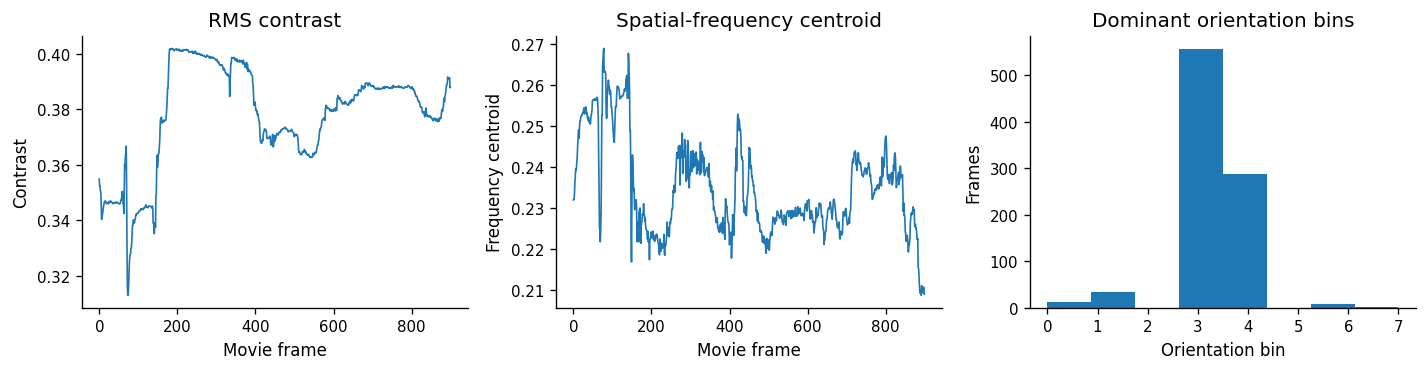

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
axes[0].plot(features["movie_frame"], features["rms_contrast"], linewidth=1.0)
axes[0].set_title("RMS contrast")
axes[0].set_xlabel("Movie frame")
axes[0].set_ylabel("Contrast")

axes[1].plot(features["movie_frame"], features["spatial_frequency_centroid"], linewidth=1.0)
axes[1].set_title("Spatial-frequency centroid")
axes[1].set_xlabel("Movie frame")
axes[1].set_ylabel("Frequency centroid")

axes[2].hist(features["dominant_orientation_bin"], bins=cfg["features"]["orientation_bins"])
axes[2].set_title("Dominant orientation bins")
axes[2].set_xlabel("Orientation bin")
axes[2].set_ylabel("Frames")

fig.tight_layout()
save_figure(fig, paths.figures_dir / "04_real_movie_frame_features.png")
plt.show()

,dominant_orientation_bin,n_samples,fraction,majority_class
0,0,13,0.014444,False
1,1,33,0.036667,False
2,3,557,0.618889,True
3,4,287,0.318889,False
4,6,8,0.008889,False
5,7,2,0.002222,False


,dominant_orientation_coarse,n_samples,fraction,majority_class
0,bin_3,557,0.618889,True
1,bin_4,287,0.318889,False
2,other,56,0.062222,False


,dominant_orientation_confident,n_samples,fraction,majority_class
0,ambiguous,450,0.500000,True
1,bin_3,392,0.435556,False
2,bin_4,58,0.064444,False


,finding,value
0,n_fine_orientation_classes,6
1,fine_orientation_majority_fraction,0.618889
2,n_coarse_orientation_classes,3
3,coarse_orientation_majority_fraction,0.618889
4,fraction_ambiguous_orientation_frames,0.5
5,dominant_confident_orientation_class,bin_3
6,minority_confident_orientation_class,bin_4
7,recommended_primary_decoding_target,continuous visual features
8,recommended_orientation_decoding_status,"secondary/exploratory with class balance, ambi..."


C:\Users\Peter\AppData\Local\Temp\ipykernel_35344\1194532002.py:54: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


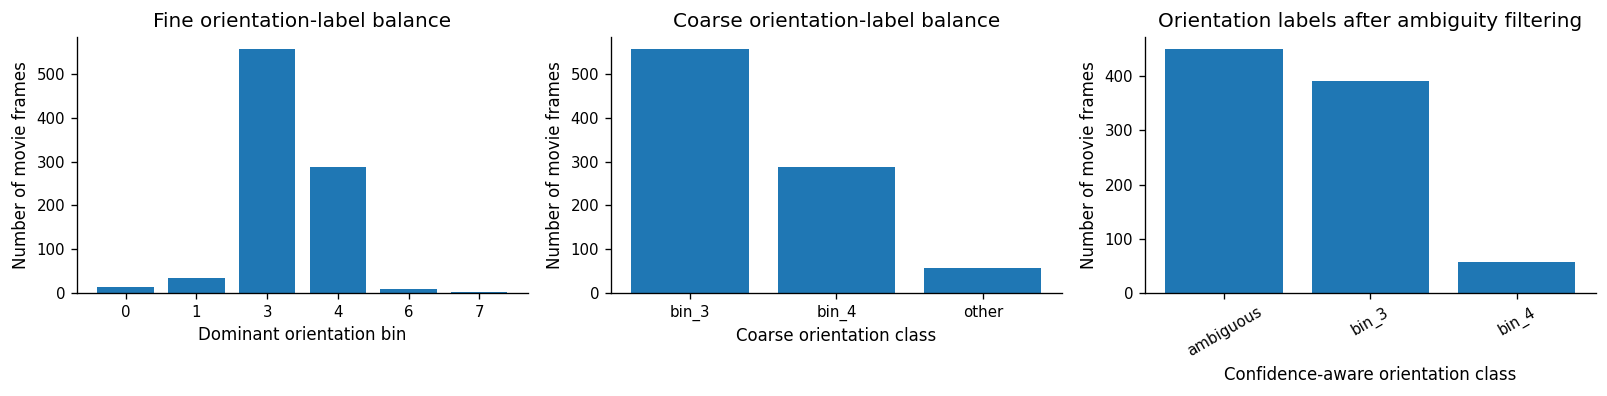

In [7]:
orientation_counts = summarize_class_balance(
    features["dominant_orientation_bin"],
    target_name="dominant_orientation_bin",
)
save_table(orientation_counts, paths.tables_dir / "04_dominant_orientation_bin_distribution.csv")

coarse_orientation_counts = summarize_class_balance(
    features["dominant_orientation_coarse"],
    target_name="dominant_orientation_coarse",
)
save_table(coarse_orientation_counts, paths.tables_dir / "04_dominant_orientation_coarse_distribution.csv")

confident_orientation_counts = summarize_class_balance(
    features["dominant_orientation_confident"],
    target_name="dominant_orientation_confident",
)
save_table(confident_orientation_counts, paths.tables_dir / "04_confident_orientation_class_distribution.csv")

orientation_interpretation = orientation_label_interpretation_table(features)
save_table(orientation_interpretation, paths.tables_dir / "04_orientation_label_interpretation.csv")

display(orientation_counts)
display(coarse_orientation_counts)
display(confident_orientation_counts)
display(orientation_interpretation)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.4))

axes[0].bar(
    orientation_counts["dominant_orientation_bin"].astype(str),
    orientation_counts["n_samples"],
)
axes[0].set_xlabel("Dominant orientation bin")
axes[0].set_ylabel("Number of movie frames")
axes[0].set_title("Fine orientation-label balance")

axes[1].bar(
    coarse_orientation_counts["dominant_orientation_coarse"].astype(str),
    coarse_orientation_counts["n_samples"],
)
axes[1].set_xlabel("Coarse orientation class")
axes[1].set_ylabel("Number of movie frames")
axes[1].set_title("Coarse orientation-label balance")

axes[2].bar(
    confident_orientation_counts["dominant_orientation_confident"].astype(str),
    confident_orientation_counts["n_samples"],
)
axes[2].set_xlabel("Confidence-aware orientation class")
axes[2].set_ylabel("Number of movie frames")
axes[2].set_title("Orientation labels after ambiguity filtering")
axes[2].tick_params(axis="x", rotation=30)

fig.tight_layout()
save_figure(fig, paths.figures_dir / "04_orientation_class_balance.png")
plt.show()


C:\Users\Peter\AppData\Local\Temp\ipykernel_35344\309373387.py:37: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


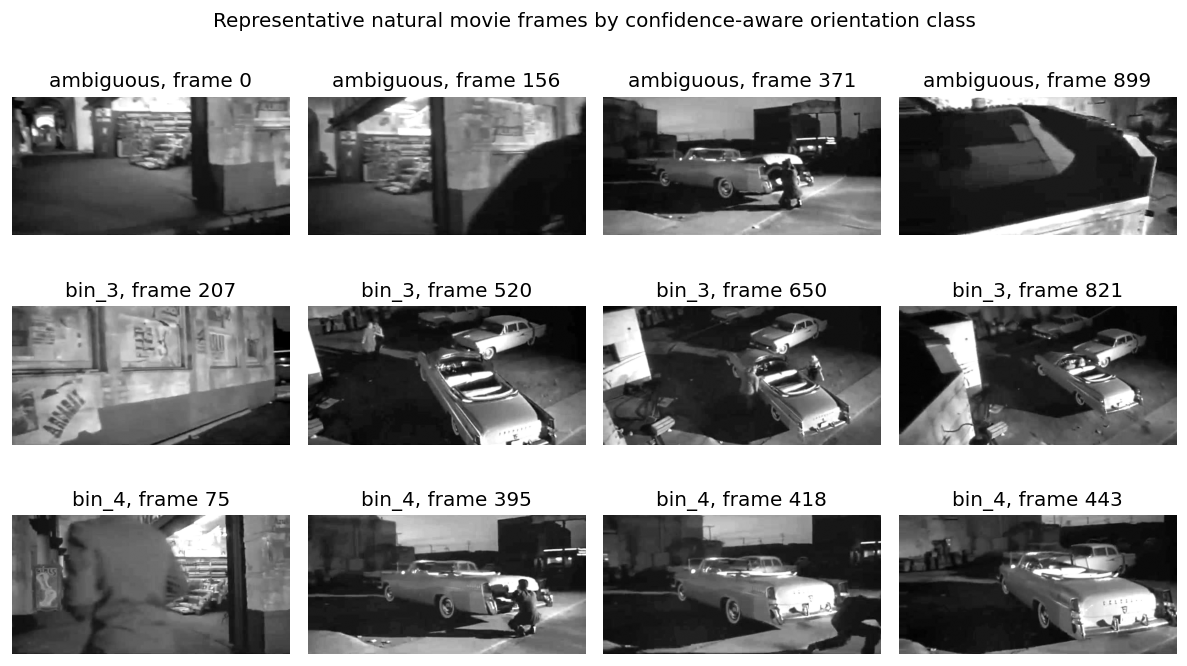

In [8]:
# I visually audit the orientation labels by sampling frames across each confidence-aware class.
# This makes it clear that the labels are derived from real movie pixels, while also
# showing why hard orientation classification is secondary for natural movies.
if movie is not None:
    movie_array = np.asarray(movie)
    classes = list(confident_orientation_counts["dominant_orientation_confident"].astype(str))
    n_examples = 4
    fig, axes = plt.subplots(len(classes), n_examples, figsize=(10, 2.0 * len(classes)))
    if len(classes) == 1:
        axes = np.asarray([axes])

    for row_idx, cls in enumerate(classes):
        frame_ids = features.loc[
            features["dominant_orientation_confident"].astype(str) == cls,
            "movie_frame",
        ].astype(int).values

        if len(frame_ids) == 0:
            for col_idx in range(n_examples):
                axes[row_idx, col_idx].axis("off")
            continue

        selected_idx = np.linspace(0, len(frame_ids) - 1, min(n_examples, len(frame_ids))).astype(int)
        selected = frame_ids[selected_idx]

        for col_idx in range(n_examples):
            ax = axes[row_idx, col_idx]
            if col_idx >= len(selected):
                ax.axis("off")
                continue
            frame_id = int(selected[col_idx])
            ax.imshow(movie_array[frame_id], cmap="gray")
            ax.set_title(f"{cls}, frame {frame_id}")
            ax.axis("off")

    fig.suptitle("Representative natural movie frames by confidence-aware orientation class")
    fig.tight_layout()
    save_figure(fig, paths.figures_dir / "04_example_movie_frames_by_confident_orientation_class.png")
    plt.show()


In [9]:
stimulus_cols = [
    "rms_contrast",
    "spatial_frequency_centroid",
    "orientation_selectivity",
    "luminance_std",
    "total_spectral_power",
]

# I report the ordinary Spearman coefficient, but I use a circular-shift null p-value
# because adjacent natural movie frames are temporally autocorrelated.
ordinary_rows = []
for target in stimulus_cols:
    rho, p = spearmanr(
        features["population_l2_norm"],
        features[target],
        nan_policy="omit",
    )
    ordinary_rows.append({
        "neural_feature": "population_l2_norm",
        "stimulus_feature": target,
        "spearman_r": rho,
        "ordinary_framewise_p": p,
    })
ordinary_corr = pd.DataFrame(ordinary_rows)

shift_corr = stimulus_neural_circular_shift_table(
    features,
    neural_col="population_l2_norm",
    stimulus_cols=stimulus_cols,
    n_perm=cfg["evaluation"].get("circular_shift_permutations", 1000),
    min_shift=cfg["evaluation"].get("circular_shift_min_frames", 60),
    seed=cfg["project"]["random_seed"],
)

stimulus_neural_checks = ordinary_corr.merge(
    shift_corr,
    on=["neural_feature", "stimulus_feature", "spearman_r"],
    how="left",
)

save_table(
    stimulus_neural_checks,
    paths.tables_dir / "04_neural_population_energy_vs_real_stimulus_features.csv",
)

display(stimulus_neural_checks)

,neural_feature,stimulus_feature,spearman_r,ordinary_framewise_p,circular_shift_p,null_mean,null_std,n_permutations,min_shift_frames
0,population_l2_norm,rms_contrast,-0.109517,9.989034e-04,0.761239,0.016950,0.230130,1000,60
1,population_l2_norm,spatial_frequency_centroid,-0.012127,7.163669e-01,0.950050,-0.006867,0.179853,1000,60
2,population_l2_norm,orientation_selectivity,-0.248246,4.169368e-14,0.564436,0.036372,0.294920,1000,60
3,population_l2_norm,luminance_std,-0.107345,1.258901e-03,0.764236,0.016656,0.230700,1000,60
4,population_l2_norm,total_spectral_power,0.070242,3.512260e-02,0.919081,-0.011082,0.282507,1000,60


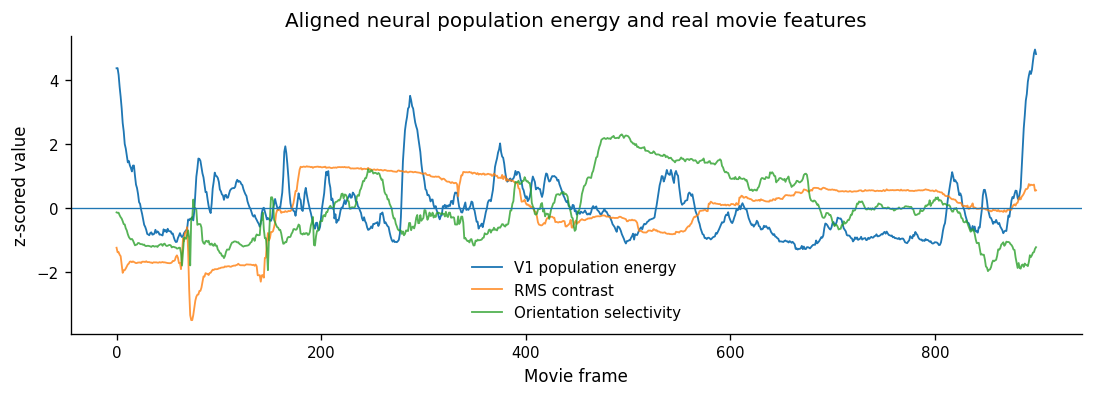

In [10]:
plot_df = features[["movie_frame", "population_l2_norm", "rms_contrast", "orientation_selectivity"]].copy()
plot_df["population_l2_norm_z"] = zscore(plot_df["population_l2_norm"], nan_policy="omit")
plot_df["rms_contrast_z"] = zscore(plot_df["rms_contrast"], nan_policy="omit")
plot_df["orientation_selectivity_z"] = zscore(plot_df["orientation_selectivity"], nan_policy="omit")

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(plot_df["movie_frame"], plot_df["population_l2_norm_z"], linewidth=1.1, label="V1 population energy")
ax.plot(plot_df["movie_frame"], plot_df["rms_contrast_z"], linewidth=1.1, alpha=0.8, label="RMS contrast")
ax.plot(plot_df["movie_frame"], plot_df["orientation_selectivity_z"], linewidth=1.1, alpha=0.8, label="Orientation selectivity")
ax.axhline(0, linewidth=0.8)
ax.set_xlabel("Movie frame")
ax.set_ylabel("z-scored value")
ax.set_title("Aligned neural population energy and real movie features")
ax.legend(frameon=False)

save_figure(fig, paths.figures_dir / "04_zscored_population_energy_and_movie_features.png")
plt.show()

In [12]:
eda_summary = pd.DataFrame({
    "metric": [
        "n_movie_frames",
        "n_cells",
        "mean_population_l2_norm",
        "std_population_l2_norm",
        "max_population_l2_norm",
        "mean_trial_variability",
        "max_trial_variability",
        "uses_fallback_labels",
        "mean_rms_contrast",
        "mean_spatial_frequency_centroid",
        "n_fine_orientation_classes",
        "fine_orientation_majority_fraction",
        "n_coarse_orientation_classes",
        "coarse_orientation_majority_fraction",
        "n_confident_orientation_classes",
        "confident_orientation_majority_fraction",
        "fraction_ambiguous_orientation_frames",
    ],
    "value": [
        R.shape[0],
        R.shape[1],
        features["population_l2_norm"].mean(),
        features["population_l2_norm"].std(),
        features["population_l2_norm"].max(),
        trial_variability.mean(),
        trial_variability.max(),
        bool(features["fallback_labels"].any()),
        features["rms_contrast"].mean(),
        features["spatial_frequency_centroid"].mean(),
        orientation_counts.shape[0],
        orientation_counts["fraction"].max(),
        coarse_orientation_counts.shape[0],
        coarse_orientation_counts["fraction"].max(),
        confident_orientation_counts.shape[0],
        confident_orientation_counts["fraction"].max(),
        confident_orientation_counts.loc[
            confident_orientation_counts["dominant_orientation_confident"].astype(str) == cfg["features"].get("orientation_ambiguous_label", "ambiguous"),
            "fraction",
        ].sum(),
    ],
})
save_table(eda_summary, paths.tables_dir / "04_exploratory_summary.csv")
display(eda_summary)


,metric,value
0,n_movie_frames,900
1,n_cells,163
2,mean_population_l2_norm,9.554914
3,std_population_l2_norm,4.916242
4,max_population_l2_norm,33.812862
5,mean_trial_variability,0.735869
6,max_trial_variability,1.097426
7,uses_fallback_labels,False
8,mean_rms_contrast,0.377728
9,mean_spatial_frequency_centroid,0.234498


In [13]:
save_table(
    features,
    paths.processed_dir / f"{base_name}_frame_features.csv",
)

save_table(
    features,
    paths.processed_dir / f"{base_name}_real_frame_features.csv",
)

WindowsPath('C:/Users/Peter/Documents/projects/NeuroAI/latent-manifold-v1-natural-movies/data/processed/session_500855614_natural_movie_one_real_frame_features.csv')